In [ ]:
# from gym_sepsis.envs.sepsis_env import SepsisEnv
# import numpy as np
# import pandas as pd

# env = SepsisEnv()

In [ ]:
# state = env.reset()

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from collections import deque
import gym

In [3]:
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size, hidden=64):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, action_size)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [ ]:
env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

q_net = QNetwork(state_size, action_size)
optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
criterion = nn.MSELoss()

gamma = 0.99
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
batch_size = 64
memory = deque(maxlen=10000)

def get_action(state):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    state = torch.FloatTensor(state).unsqueeze(0)
    with torch.no_grad():
        q_values = q_net(state)
    return q_values.argmax().item()

def replay():
    if len(memory) < batch_size:
        return
    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)
    
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions).unsqueeze(1)
    rewards = torch.FloatTensor(rewards).unsqueeze(1)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones).unsqueeze(1)
    
    q_values = q_net(states).gather(1, actions)
    next_q_values = q_net(next_states).max(1, keepdim=True)[0].detach()
    targets = rewards + (1 - dones) * gamma * next_q_values
    
    loss = criterion(q_values, targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


episodes = 500
reward_vec = np.zeros(episodes)
epsilon_vec = np.zeros(episodes)
for e in range(episodes):
    state = env.reset()
    done = False
    total_reward = 0
    
    while not done:
        action = get_action(state)
        next_state, reward, done, info = env.step(action)
        memory.append((state, action, reward, next_state, float(done)))
        state = next_state
        total_reward += reward
        
        replay()
    
    reward_vec[e] = total_reward
    epsilon_vec[e] = epsilon

    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    print(f"Episode {e+1}: Reward={total_reward:.1f}, Epsilon={epsilon:.3f}")


Episode 1: Reward=26.0, Epsilon=0.995
Episode 2: Reward=11.0, Epsilon=0.990
Episode 3: Reward=11.0, Epsilon=0.985
Episode 4: Reward=15.0, Epsilon=0.980


Episode 5: Reward=17.0, Epsilon=0.975
Episode 6: Reward=20.0, Epsilon=0.970
Episode 7: Reward=16.0, Epsilon=0.966
Episode 8: Reward=20.0, Epsilon=0.961
Episode 9: Reward=28.0, Epsilon=0.956
Episode 10: Reward=24.0, Epsilon=0.951
Episode 11: Reward=28.0, Epsilon=0.946
Episode 12: Reward=15.0, Epsilon=0.942
Episode 13: Reward=15.0, Epsilon=0.937
Episode 14: Reward=54.0, Epsilon=0.932
Episode 15: Reward=11.0, Epsilon=0.928
Episode 16: Reward=14.0, Epsilon=0.923
Episode 17: Reward=13.0, Epsilon=0.918
Episode 18: Reward=15.0, Epsilon=0.914
Episode 19: Reward=16.0, Epsilon=0.909
Episode 20: Reward=22.0, Epsilon=0.905
Episode 21: Reward=13.0, Epsilon=0.900
Episode 22: Reward=16.0, Epsilon=0.896
Episode 23: Reward=13.0, Epsilon=0.891
Episode 24: Reward=12.0, Epsilon=0.887
Episode 25: Reward=14.0, Epsilon=0.882
Episode 26: Reward=46.0, Epsilon=0.878
Episode 27: Reward=27.0, Epsilon=0.873
Episode 28: Reward=46.0, Epsilon=0.869
Episode 29: Reward=14.0, Epsilon=0.865
Episode 30: Reward=25.0, Epsil

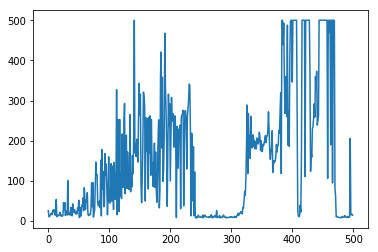

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(range(episodes), reward_vec, ls = "-")
fig.savefig("plot1")
plt.show()